In [842]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [843]:
import matplotlib.pyplot as plt
import mpmath
import numpy as np
from koala import graph_utils as gu
from koala import plotting as pl
from koala.flux_finder import ujk_from_fluxes
from scipy import linalg as la

from dimer_models.kasteleyn import (
    fast_pfaffian_as_mpmath,
    find_omega,
    generate_kasteleyn_orientation,
    generate_torus_orientations,
    kasteleyn_matrix,
    torus_dimer_correlation,
    torus_dimer_probabilities,
    torus_monomer_count,
    torus_vison_correlation,
)

# mpmath.mp.dps = 50
from dimer_models.lattice_generation import bipartite_squarefull


In [844]:
# del lattice

In [845]:
def dimer_dimer_prob(dimerisations, chosen_edges):
    e = np.array([dimerisations[:, x] for x in chosen_edges])
    return np.average(e.prod(axis=0))

In [846]:
try:
    lattice
except NameError:
    lattice = bipartite_squarefull(40)
    lattice = gu.tutte_embedding(lattice)
rng = np.random.default_rng(123)

In [847]:
pos = np.array([[0.25, 0.25], [0.75, 0.75]])

chosen_vertices = [np.argmin(la.norm(lattice.vertices.positions - p, axis=1)) for p in pos]
chosen_vertices = rng.choice(lattice.n_vertices, 2, False)
chosen_plaquettes = lattice.vertices.adjacent_plaquettes[chosen_vertices][:, -1]

# these test dimer correlations
randomly_chosen_edges = np.array([rng.choice(range(lattice.n_edges), 3, False) for _ in range(10)])

randomly_chosen_edges

array([[53, 13,  3],
       [10, 19, 20],
       [53, 26, 16],
       [ 1, 49, 52],
       [58, 14, 49],
       [ 8, 23, 43],
       [53, 43, 13],
       [30, 47, 12],
       [29,  0,  9],
       [10, 21, 24]])

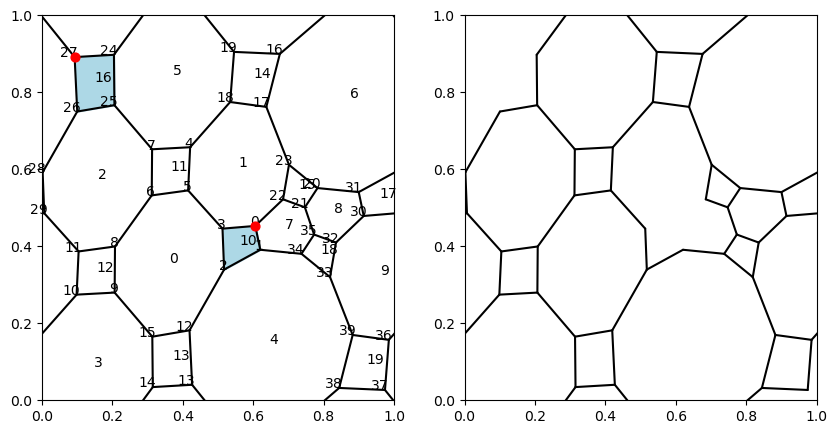

In [848]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))


reduced_lattice = gu.remove_vertices(lattice, chosen_vertices)

pl.plot_edges(lattice, ax=ax[0])
pl.plot_edges(reduced_lattice, ax=ax[1])
pl.plot_plaquettes(
    lattice, subset=chosen_plaquettes, zorder=-10, color_scheme=["lightblue"], ax=ax[0]
)

pl.plot_vertex_indices(lattice, ax=ax[0])
pl.plot_plaquette_indices(lattice, ax=ax[0])

chosen_positions = lattice.vertices.positions[chosen_vertices]
ax[0].scatter(*chosen_positions.T, zorder=10, c="r", s=40)

plt.show()

In [849]:
# brute force dimerisations
dimerisations = gu.dimerise(lattice, -1)
monomer_dimerisations = gu.dimerise(reduced_lattice, -1)
dimer_probabilities = np.average(dimerisations, axis=0)
dimer_dimer_probabilities = np.array(
    [dimer_dimer_prob(dimerisations, c) for c in randomly_chosen_edges]
)
n_dimerisations = dimerisations.shape[0]
n_monomer_dimerisations = monomer_dimerisations.shape[0]

print(f"n_dimers: {n_dimerisations}\n")
print(f"n_monomer_dimerisations: {n_monomer_dimerisations}\n")
print(f"monomer_probabilities: {n_monomer_dimerisations / n_dimerisations}\n")
print(f"dimer_probabilities\n{dimer_probabilities}\n")
print(f"dimer_dimer_probabilities\n{dimer_dimer_probabilities}\n")

n_dimers: 2868

n_monomer_dimerisations: 328

monomer_probabilities: 0.11436541143654114

dimer_probabilities
[0.18898187 0.19002789 0.19281729 0.17921897 0.19177127 0.16910739
 0.20432357 0.19281729 0.19456067 0.20432357 0.16910739 0.22977685
 0.19456067 0.20711297 0.19351464 0.18898187 0.19177127 0.17921897
 0.19351464 0.17085077 0.41841004 0.38702929 0.43375174 0.37726639
 0.41701534 0.39400279 0.41596932 0.39121339 0.41596932 0.39121339
 0.41701534 0.39400279 0.41178522 0.39470014 0.39818689 0.40899582
 0.42608089 0.40481172 0.40341702 0.40306834 0.38842399 0.38179916
 0.41387727 0.41701534 0.39818689 0.40899582 0.41178522 0.39470014
 0.43375174 0.37726639 0.41841004 0.38702929 0.41387727 0.41701534
 0.38842399 0.38179916 0.40341702 0.40306834 0.42608089 0.40481172]

dimer_dimer_probabilities
[0.0083682  0.01847978 0.02126918 0.0251046  0.01778243 0.
 0.03033473 0.02998605 0.02057183 0.01359833]



First check that the number of dimerisations is right

In [850]:
# compute the four kasteleyn matrices
initial_ujk = generate_kasteleyn_orientation(lattice)
orientations = generate_torus_orientations(lattice, initial_ujk)
kasteleyn_matrices = np.array([kasteleyn_matrix(lattice, o) for o in orientations])

# find inverses and pfaffians
pfaffians = np.array([fast_pfaffian_as_mpmath(k) for k in kasteleyn_matrices])

# find n_dimerisations from pfaffian
omega = find_omega(pfaffians)
n_dimerisations_pfaff = int(mpmath.nint(abs(sum(omega * pfaffians) / 2)))


print(n_dimerisations_pfaff)
assert n_dimerisations - n_dimerisations_pfaff == 0, f"{n_dimerisations - n_dimerisations_pfaff}"
print("counting dimerisations correctly")
# check its all correct
for j, k in enumerate(kasteleyn_matrices):
    assert np.all(k + k.T == 0)

2868
counting dimerisations correctly


In [851]:
# find probabilities per edge
inverses = np.array([la.inv(k) for k in kasteleyn_matrices])
probs_k = torus_dimer_probabilities(lattice, kasteleyn_matrices, inverses, pfaffians, omega)

assert np.allclose(probs_k - dimer_probabilities, 0)
print("counting probabilities correctly")

counting probabilities correctly


In [852]:
multi_probabilities = []
for edges in randomly_chosen_edges:
    out = torus_dimer_correlation(lattice, kasteleyn_matrices, inverses, pfaffians, omega, edges)
    multi_probabilities.append(out)
assert np.allclose((multi_probabilities - dimer_dimer_probabilities).astype(float), 0)

print("counting dimer-dimer correlations correctly")

counting dimer-dimer correlations correctly


In [853]:
# make tilde kasteleyn
# monomer_fluxes = np.array([-1] * lattice.n_plaquettes)
# for x in chosen_plaquettes:
#     monomer_fluxes[x] *= -1

# monomer_ujk = ujk_from_fluxes(lattice, monomer_fluxes, initial_ujk)


monomer_ujk = generate_kasteleyn_orientation(lattice, chosen_plaquettes, initial_ujk)

monomer_orientations = generate_torus_orientations(lattice, monomer_ujk)
kasteleyn_tilde_matrices = np.array([kasteleyn_matrix(lattice, o) for o in monomer_orientations])

pfaffians_tilde = np.array([fast_pfaffian_as_mpmath(k) for k in kasteleyn_tilde_matrices])
inverses_tilde = np.array(
    [
        np.zeros_like(k) if abs(pf) < 1e-10 else la.inv(k)
        for k, pf in zip(kasteleyn_tilde_matrices, pfaffians_tilde, strict=True)
    ]
)
n_monomers_pfaff = torus_monomer_count(
    kasteleyn_tilde_matrices, inverses_tilde, pfaffians_tilde, chosen_vertices
)

print(n_monomers_pfaff)
assert (n_monomers_pfaff - n_monomer_dimerisations) == 0, (
    f"{n_monomers_pfaff - n_monomer_dimerisations}"
)

print("counting monomers correctly")

328.0
counting monomers correctly


In [855]:
# inverses_tilde_restricted = inverses_tilde[:, *np.ix_(chosen_vertices, chosen_vertices)]
# inverses_tilde_pfaffs = np.array([fast_pfaffian_as_mpmath(k) for k in inverses_tilde_restricted])

# if np.sum(np.abs(inverses_tilde_pfaffs)) < 1e-10:
#     inverses_tilde_pfaffs = np.ones(4)

n_vison_pfaff = torus_vison_correlation(pfaffians_tilde, omega)

flip_edges = np.where(monomer_ujk - initial_ujk)[0]
sign = np.prod((-1) ** dimerisations[:, flip_edges], axis=1)
brute_force_visons = abs(np.sum(sign))

print(brute_force_visons, n_vison_pfaff)
assert n_vison_pfaff == brute_force_visons
print("visons correct")

116 116.0
visons correct


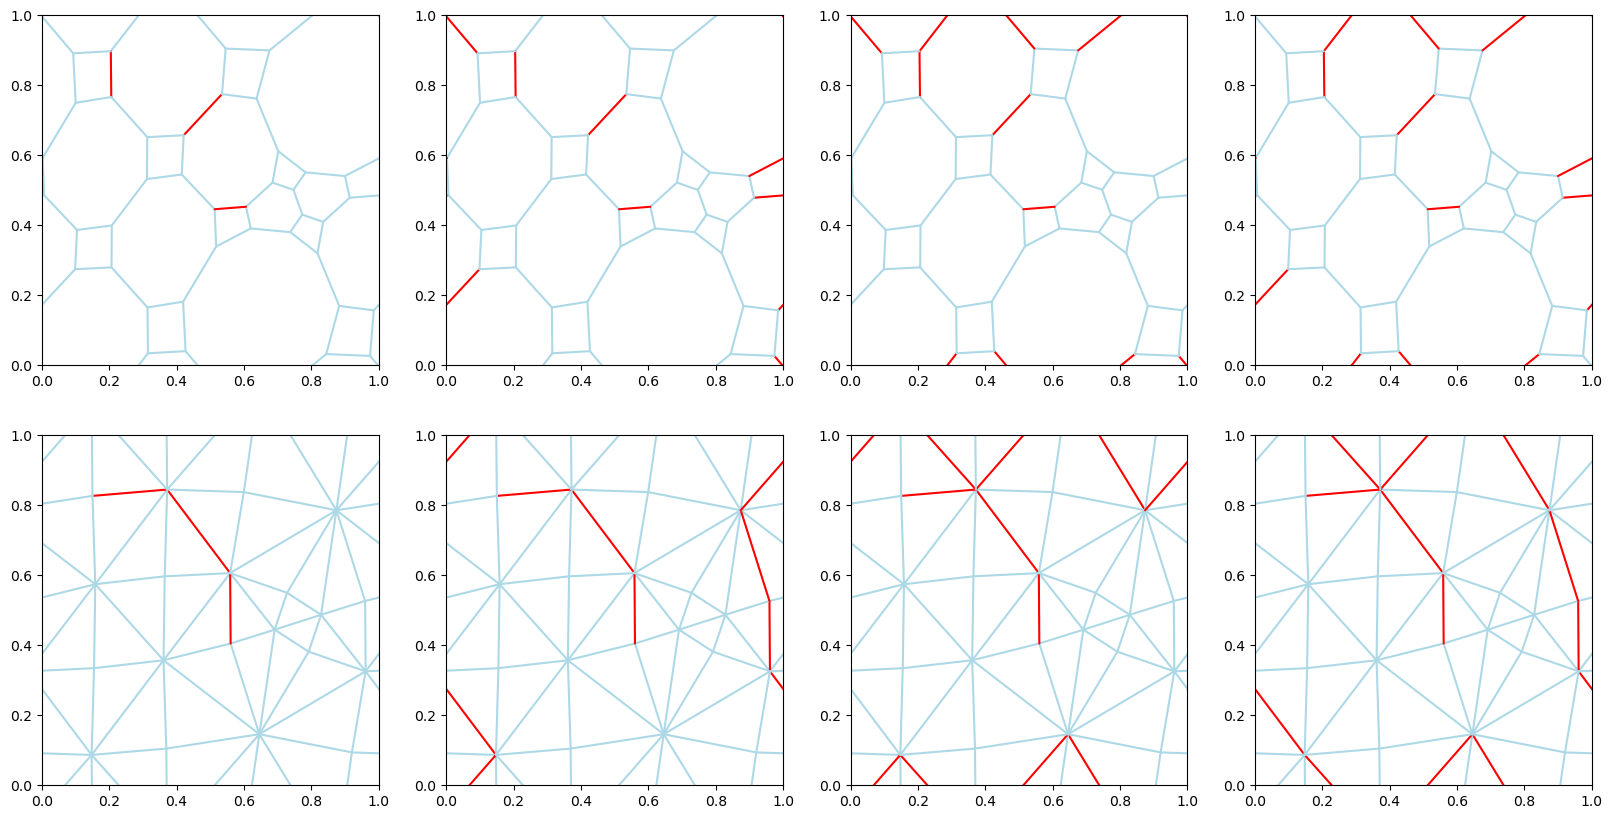

In [856]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))

for ii in range(4):
    ujk_diff = 1 - (monomer_orientations[ii] == initial_ujk)
    pl.plot_edges(lattice, ax=ax[0, ii], labels=ujk_diff, color_scheme=["lightblue", "red"])
    pl.plot_edges(
        gu.make_dual(lattice, reg_steps=0),
        ax=ax[1, ii],
        labels=ujk_diff,
        color_scheme=["lightblue", "red"],
    )

In [857]:
del lattice